## Разведочный анализ данных (EDA)

- используем полный датасет `data/dataset_autos_full.txt`
- для анализа будем использовать модифицированную версию инструмента eda_cli из HW03

### Импорты

In [21]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from pandas.api import types as ptypes

### Вспомогательные структуры данных

In [22]:
@dataclass
class ColumnSummary:
    name: str
    dtype: str
    non_null: int
    missing: int
    missing_share: float
    unique: int
    example_values: List[Any]
    is_numeric: bool
    min: Optional[float] = None
    max: Optional[float] = None
    mean: Optional[float] = None
    std: Optional[float] = None

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


@dataclass
class DatasetSummary:
    n_rows: int
    n_cols: int
    columns: List[ColumnSummary]

    def to_dict(self) -> Dict[str, Any]:
        return {
            "n_rows": self.n_rows,
            "n_cols": self.n_cols,
            "columns": [c.to_dict() for c in self.columns],
        }

### Функции для анализа данных

In [23]:
def summarize_dataset(
    df: pd.DataFrame,
    example_values_per_column: int = 3,
) -> DatasetSummary:
    """
    Полный обзор датасета по колонкам:
    - количество строк/столбцов;
    - типы;
    - пропуски;
    - количество уникальных;
    - несколько примерных значений;
    - базовые числовые статистики (для numeric).
    """
    n_rows, n_cols = df.shape
    columns: List[ColumnSummary] = []

    for name in df.columns:
        s = df[name]
        dtype_str = str(s.dtype)

        non_null = int(s.notna().sum())
        missing = n_rows - non_null
        missing_share = float(missing / n_rows) if n_rows > 0 else 0.0
        unique = int(s.nunique(dropna=True))

        examples = (
            s.dropna().astype(str).unique()[:example_values_per_column].tolist()
            if non_null > 0
            else []
        )

        is_numeric = bool(ptypes.is_numeric_dtype(s))
        min_val: Optional[float] = None
        max_val: Optional[float] = None
        mean_val: Optional[float] = None
        std_val: Optional[float] = None

        if is_numeric and non_null > 0:
            min_val = float(s.min())
            max_val = float(s.max())
            mean_val = float(s.mean())
            std_val = float(s.std())

        columns.append(
            ColumnSummary(
                name=name,
                dtype=dtype_str,
                non_null=non_null,
                missing=missing,
                missing_share=missing_share,
                unique=unique,
                example_values=examples,
                is_numeric=is_numeric,
                min=min_val,
                max=max_val,
                mean=mean_val,
                std=std_val,
            )
        )

    return DatasetSummary(n_rows=n_rows, n_cols=n_cols, columns=columns)


def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    """Таблица пропусков по колонкам: count/share."""
    if df.empty:
        return pd.DataFrame(columns=["missing_count", "missing_share"])

    total = df.isna().sum()
    share = total / len(df)
    return (
        pd.DataFrame({"missing_count": total, "missing_share": share})
        .sort_values("missing_share", ascending=False)
    )


def correlation_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Корреляция Пирсона для числовых колонок."""
    numeric_df = df.select_dtypes(include="number")
    if numeric_df.empty:
        return pd.DataFrame()
    return numeric_df.corr(numeric_only=True)


def top_categories(
    df: pd.DataFrame,
    max_columns: int = 10,
    top_k: int = 5,
) -> Dict[str, pd.DataFrame]:
    """
    Для категориальных/строковых колонок считает top-k значений.
    Возвращает словарь: колонка -> DataFrame со столбцами value/count/share.
    """
    result: Dict[str, pd.DataFrame] = {}
    candidate_cols: List[str] = [
        name for name in df.columns
        if ptypes.is_object_dtype(df[name]) or isinstance(df[name].dtype, pd.CategoricalDtype)
    ]

    for name in candidate_cols[:max_columns]:
        s = df[name]
        vc = s.value_counts(dropna=True).head(top_k)
        if vc.empty:
            continue
        share = vc / vc.sum()
        result[name] = pd.DataFrame(
            {"value": vc.index.astype(str), "count": vc.values, "share": share.values}
        )

    return result


def problematic_columns(
    summary: DatasetSummary,
    min_missing_share: float,
) -> pd.DataFrame:
    """Таблица проблемных колонок: название / доля пропусков."""
    rows = [
        {"column_name": col.name, "missing_share": col.missing_share}
        for col in summary.columns
        if col.missing_share >= min_missing_share
    ]
    return pd.DataFrame(rows)


def count_complete_rows(df: pd.DataFrame) -> tuple[int, float]:
    """
    Возвращает число и долю строк, в которых нет ни одного пропущенного значения.
    """
    n_complete_rows = int(df.notna().all(axis=1).sum())
    complete_rows_share = (n_complete_rows / len(df))
    return n_complete_rows, complete_rows_share


def count_anomalies(
    df: pd.DataFrame,
    ignore_names: list[str],
    clip_quantile: float = 0.99,
) -> pd.DataFrame:
    """
    Для числовых колонок считает количество и долю аномальных значений —
    тех, что выходят за пределы [1-clip_quantile, clip_quantile].
    """
    numeric_df = df.select_dtypes(include="number")
    rows = []

    for name in numeric_df.columns:
        s = numeric_df[name].dropna()
        if s.empty or s.name in ignore_names:
            continue

        lo = s.quantile(1 - clip_quantile)
        hi = s.quantile(clip_quantile)
        outlier_count = int(((s < lo) | (s > hi)).sum())

        rows.append({
            "column": name,
            "outlier_count": outlier_count,
            "outlier_share": outlier_count / len(s),
            "lower_bound": lo,
            "upper_bound": hi,
        })

    return pd.DataFrame(rows).sort_values("outlier_share", ascending=False)


def compute_quality_flags(summary: DatasetSummary, missing_df: pd.DataFrame) -> Dict[str, Any]:
    """Простейшие эвристики «качества» данных."""
    flags: Dict[str, Any] = {}
    flags["too_few_rows"] = summary.n_rows < 100
    flags["too_many_columns"] = summary.n_cols > 100

    max_missing_share = float(missing_df["missing_share"].max()) if not missing_df.empty else 0.0
    flags["max_missing_share"] = max_missing_share
    flags["too_many_missing"] = max_missing_share > 0.5

    has_sus_id_dupes = any(
        el.name == "index" and el.unique != el.non_null
        for el in summary.columns
    )
    flags["has_suspicious_id_duplicates"] = has_sus_id_dupes

    has_constant_columns = any(col.unique == 1 for col in summary.columns)
    flags["has_constant_columns"] = has_constant_columns

    score = 1.0
    score -= max_missing_share
    if summary.n_rows < 100:
        score -= 0.2
    if summary.n_cols > 100:
        score -= 0.1
    if has_sus_id_dupes:
        score -= 0.13
    if has_constant_columns:
        score -= 0.16

    flags["quality_score"] = max(0.0, min(1.0, score))
    return flags


def flatten_summary_for_print(summary: DatasetSummary) -> pd.DataFrame:
    """Превращает DatasetSummary в табличку для более удобного вывода."""
    return pd.DataFrame([
        {
            "name": col.name,
            "dtype": col.dtype,
            "non_null": col.non_null,
            "missing": col.missing,
            "missing_share": col.missing_share,
            "unique": col.unique,
            "is_numeric": col.is_numeric,
            "min": col.min,
            "max": col.max,
            "mean": col.mean,
            "std": col.std,
        }
        for col in summary.columns
    ])

### Функции для визуализации

In [24]:
def plot_histograms_per_column(
    df: pd.DataFrame,
    max_columns: int = 6,
    bins: int = 30,
    clip_quantile: float = 0.99,
) -> None:
    """Для числовых колонок строит по отдельной гистограмме.
    Выбросы выше clip_quantile обрезаются для читаемого распределения по оси X.
    """
    numeric_df = df.select_dtypes(include="number")
    cols = list(numeric_df.columns[:max_columns])

    if not cols:
        display(Markdown("_Числовых колонок не найдено._"))
        return

    for name in cols:
        s = numeric_df[name].dropna()
        if s.empty or s.name == "index":
            continue

        lo = s.quantile(1 - clip_quantile)
        hi = s.quantile(clip_quantile)
        s_clipped = s[(s >= lo) & (s <= hi)]

        fig, ax = plt.subplots()
        ax.hist(s_clipped.values, bins=bins)
        ax.set_title(f"Histogram of {name} (p{int((1-clip_quantile)*100)}–p{int(clip_quantile*100)})")
        ax.set_xlabel(name)
        ax.set_ylabel("Count")
        fig.tight_layout()
        plt.show()
        plt.close(fig)


def plot_missing_matrix(df: pd.DataFrame) -> None:
    """Визуализация пропусков: где True=пропуск, False=значение."""
    if df.empty:
        display(Markdown("_Датасет пуст._"))
        return

    mask = df.isna().values
    fig, ax = plt.subplots(figsize=(min(12, df.shape[1] * 0.4), 4))
    ax.imshow(mask, aspect="auto", interpolation="none")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Rows")
    ax.set_title("Missing values matrix")
    ax.set_xticks(range(df.shape[1]))
    ax.set_xticklabels(df.columns, rotation=90, fontsize=8)
    ax.set_yticks([])
    fig.tight_layout()
    plt.show()
    plt.close(fig)

### Параметры запуска

In [25]:
CSV_PATH          = "../data/dataset_autos_full.csv"   # путь к CSV-файлу
SEP               = ","          # разделитель
ENCODING          = "utf-8"      # кодировка
MAX_HIST_COLUMNS  = 6            # максимум числовых колонок для гистограмм
MIN_MISSING_SHARE = 0.5          # порог для «проблемных» колонок
CLIP_QUANTILE     = 0.99         # перцентиль для аномальных значений

---
### 1. Загрузка данных

In [26]:
df = pd.read_csv(CSV_PATH, sep=SEP, encoding=ENCODING)
display(Markdown(f"**Файл:** `{CSV_PATH}`  \n**Строк:** {df.shape[0]}  \n**Столбцов:** {df.shape[1]}"))
df.head()

**Файл:** `../data/dataset_autos_full.csv`  
**Строк:** 371528  
**Столбцов:** 21

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


---
### 2. Обзор колонок

In [27]:
summary     = summarize_dataset(df)
summary_df  = flatten_summary_for_print(summary)

display(Markdown("### Сводная таблица по колонкам"))
display(summary_df)

display(Markdown(f"### Числовых колонок: {summary_df["dtype"].to_list().count("int64")}"))
display(Markdown(f"### Категориальных колонок: {summary_df["dtype"].to_list().count("object")}"))

### Сводная таблица по колонкам

,name,dtype,non_null,missing,missing_share,unique,is_numeric,min,max,mean,std
0,index,int64,371528,0,0.000000,371528,True,0.0,3.715270e+05,185763.500000,1.072510e+05
1,dateCrawled,object,371528,0,0.000000,280500,False,NaN,NaN,NaN,NaN
2,name,object,371528,0,0.000000,233531,False,NaN,NaN,NaN,NaN
3,seller,object,371528,0,0.000000,2,False,NaN,NaN,NaN,NaN
4,offerType,object,371528,0,0.000000,2,False,NaN,NaN,NaN,NaN
5,price,int64,371528,0,0.000000,5597,True,0.0,2.147484e+09,17295.141865,3.587954e+06
6,abtest,object,371528,0,0.000000,2,False,NaN,NaN,NaN,NaN
7,vehicleType,object,333659,37869,0.101928,8,False,NaN,NaN,NaN,NaN
8,yearOfRegistration,int64,371528,0,0.000000,155,True,1000.0,9.999000e+03,2004.577997,9.286660e+01
9,gearbox,object,351319,20209,0.054394,2,False,NaN,NaN,NaN,NaN


### Числовых колонок: 8

### Категориальных колонок: 13

---
### 3. Качество данных (эвристики)

In [28]:
missing_df    = missing_table(df)
quality_flags = compute_quality_flags(summary, missing_df)

display(Markdown(f"""
| Метрика | Значение |
|---------|----------|
| Оценка качества | **{quality_flags['quality_score']:.2f}** |
| Макс. доля пропусков по колонке | **{quality_flags['max_missing_share']:.2%}** |
| Слишком мало строк (<100) | **{quality_flags['too_few_rows']}** |
| Слишком много колонок (>100) | **{quality_flags['too_many_columns']}** |
| Слишком много пропусков | **{quality_flags['too_many_missing']}** |
| Есть константные колонки | **{quality_flags['has_constant_columns']}** |
| id не уникален | **{quality_flags['has_suspicious_id_duplicates']}** |
"""))


| Метрика | Значение |
|---------|----------|
| Оценка качества | **0.65** |
| Макс. доля пропусков по колонке | **19.40%** |
| Слишком мало строк (<100) | **False** |
| Слишком много колонок (>100) | **False** |
| Слишком много пропусков | **False** |
| Есть константные колонки | **True** |
| id не уникален | **False** |


---
### 4. Пропуски

### Таблица пропусков по колонкам

,missing_count,missing_share
notRepairedDamage,72060,0.193956
vehicleType,37869,0.101928
fuelType,33386,0.089861
model,20484,0.055134
gearbox,20209,0.054394
offerType,0,0.000000
seller,0,0.000000
name,0,0.000000
dateCrawled,0,0.000000
index,0,0.000000


### Матрица пропусков

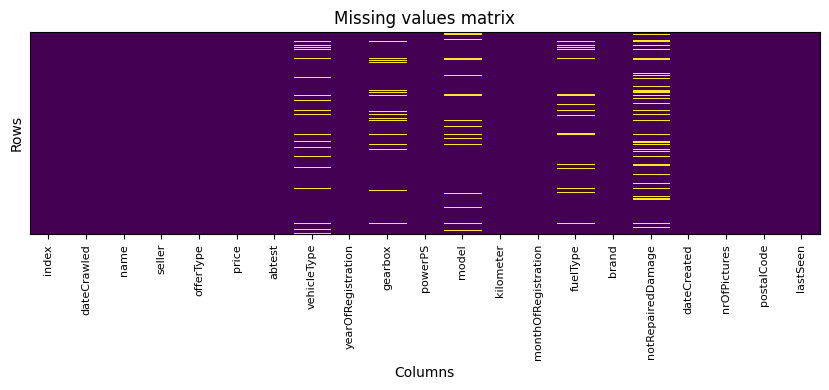

In [29]:
if missing_df.empty:
    display(Markdown("_Пропусков нет или датасет пуст._"))
else:
    display(Markdown("### Таблица пропусков по колонкам"))
    display(missing_df)
    display(Markdown("### Матрица пропусков"))
    plot_missing_matrix(df)

---
### 5. Строки без пропусков

In [30]:
n_complete_rows, complete_rows_share = count_complete_rows(df)
display(Markdown(f"Число строк без пропусков: {n_complete_rows}"))
display(Markdown(f"Доля строк без пропусков: {complete_rows_share:.2%}"))

Число строк без пропусков: 260956

Доля строк без пропусков: 70.24%

---
### 6. Проблемные колонки

In [31]:
problematic_cols_df = problematic_columns(summary, MIN_MISSING_SHARE)

if problematic_cols_df.empty:
    display(Markdown(f"_Нет колонок с долей пропусков ≥ {MIN_MISSING_SHARE:.0%}._"))
else:
    display(Markdown(f"### Колонки с долей пропусков ≥ {MIN_MISSING_SHARE:.0%}"))
    display(problematic_cols_df)

_Нет колонок с долей пропусков ≥ 50%._

---
### 7. Аномальные значения числовых признаков

In [32]:
anomalies_df = count_anomalies(df, ignore_names=["index", "postalCode"], clip_quantile=CLIP_QUANTILE)
anomalies_df

,column,outlier_count,outlier_share,lower_bound,upper_bound
0,price,3686,0.009921,0.0,36000.0
1,yearOfRegistration,3641,0.009800,1978.0,2018.0
2,powerPS,3565,0.009596,0.0,340.0
3,kilometer,0,0.000000,5000.0,150000.0
4,monthOfRegistration,0,0.000000,0.0,12.0
5,nrOfPictures,0,0.000000,0.0,0.0


---
### 8. Категориальные признаки

In [35]:
top_cats = top_categories(df, max_columns=13, top_k=10)

if not top_cats:
    display(Markdown("_Категориальные/строковые признаки не найдены._"))
else:
    for col_name, table in top_cats.items():
        display(Markdown(f"### `{col_name}` — топ значений"))
        display(table)

### `dateCrawled` — топ значений

,value,count,share
0,2016-03-24 14:49:47,7,0.129630
1,2016-03-26 22:57:31,6,0.111111
2,2016-03-19 21:49:56,6,0.111111
3,2016-03-11 15:36:59,5,0.092593
4,2016-03-22 15:50:32,5,0.092593
5,2016-03-27 12:50:22,5,0.092593
6,2016-03-21 14:50:20,5,0.092593
7,2016-04-02 14:50:21,5,0.092593
8,2016-03-31 17:57:07,5,0.092593
9,2016-04-01 19:25:23,5,0.092593


### `name` — топ значений

,value,count,share
0,Ford_Fiesta,657,0.124267
1,BMW_318i,627,0.118593
2,Opel_Corsa,622,0.117647
3,Volkswagen_Golf_1.4,603,0.114053
4,BMW_316i,523,0.098922
5,BMW_320i,492,0.093058
6,Volkswagen_Polo,475,0.089843
7,Renault_Twingo,447,0.084547
8,Volkswagen_Golf,428,0.080953
9,Volkswagen_Golf_1.6,413,0.078116


### `seller` — топ значений

...

,value,count,share
0,nein,263182,0.878832
1,ja,36286,0.121168


### `dateCreated` — топ значений

,value,count,share
0,2016-04-03 00:00:00,14450,0.108301
1,2016-04-04 00:00:00,14022,0.105094
2,2016-03-20 00:00:00,13547,0.101533
3,2016-03-12 00:00:00,13379,0.100274
4,2016-03-21 00:00:00,13305,0.099720
5,2016-03-14 00:00:00,13088,0.098093
6,2016-03-28 00:00:00,13069,0.097951
7,2016-04-02 00:00:00,12991,0.097366
8,2016-03-07 00:00:00,12821,0.096092
9,2016-03-19 00:00:00,12752,0.095575


### `lastSeen` — топ значений

,value,count,share
0,2016-04-06 13:45:54,17,0.104938
1,2016-04-07 06:45:59,17,0.104938
2,2016-04-07 08:16:54,16,0.098765
3,2016-04-06 09:46:00,16,0.098765
4,2016-04-06 04:17:20,16,0.098765
5,2016-04-07 08:45:09,16,0.098765
6,2016-04-06 07:45:46,16,0.098765
7,2016-04-06 01:15:23,16,0.098765
8,2016-04-07 07:46:26,16,0.098765
9,2016-04-06 09:44:33,16,0.098765


---
### 9. Гистограммы числовых колонок

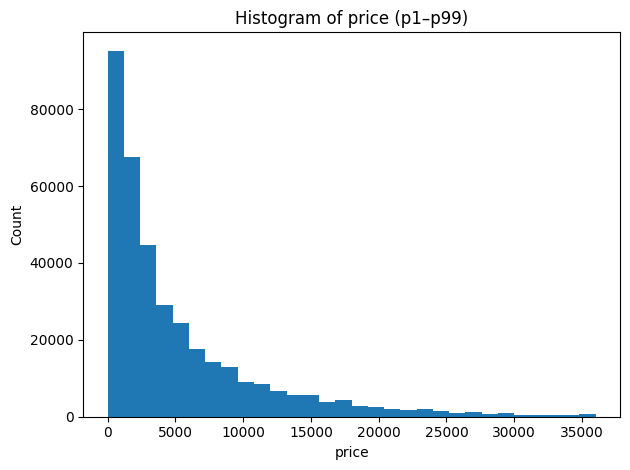

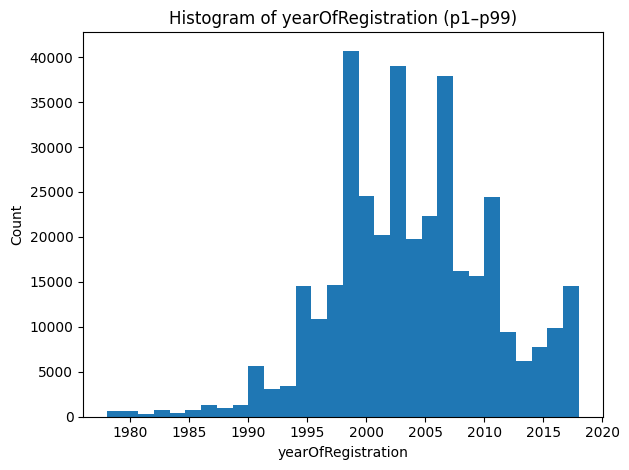

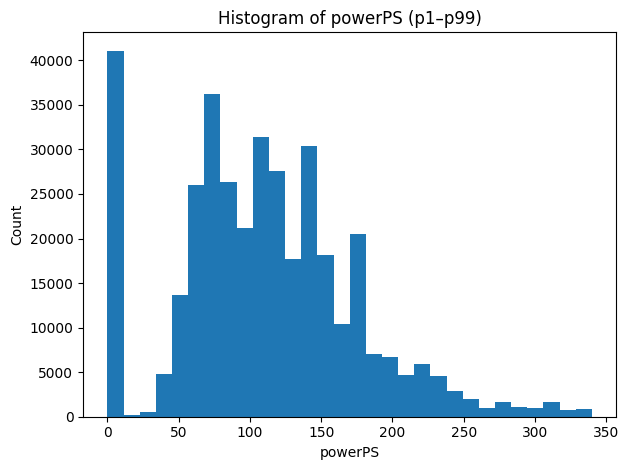

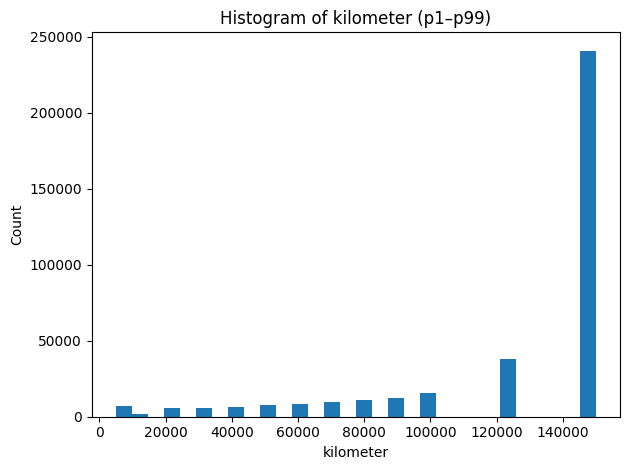

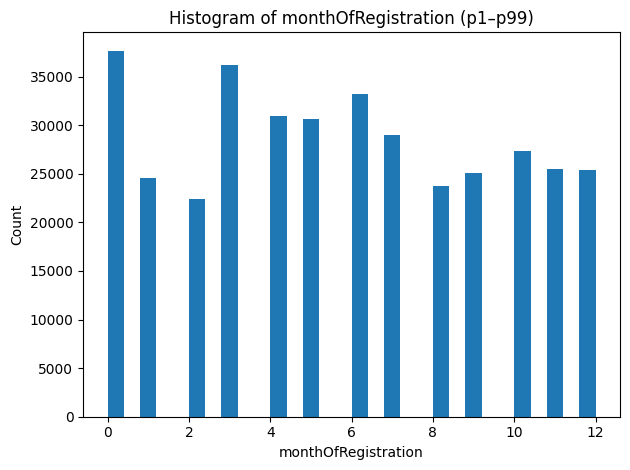

In [34]:
plot_histograms_per_column(df, max_columns=MAX_HIST_COLUMNS, clip_quantile=CLIP_QUANTILE)

## Краткие выводы

- В датасете 371528 строк и 20 признаков, не считая идентификатора записи.
- Числовых колонок: 8
- Категориальных колонок: 13
- Присутствует константная числовая колонка `nrOfPictures`
- В качестве идентификатора записи выступает числовая колонка `index`, она не содержит пропусков и дубликатов
- Доля строк, для которых ни во одном из полей нет пропусков, составляет 70.24%
- Присутствуют аномальные значения в колонках `price`, `yearOfRegistration`, `powerPS`.
- В бинарных категориальных колонках `seller` и `offerType` сильнейший дизбаланс значений 